In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/exposure_nairobi_with_hazard.csv")

# See the column names
print(df.columns)            # Index(['name', 'age', 'city'], dtype='object')
print(list(df.columns))      # ['name', 'age', 'city']


Index(['loc_id', 'lat', 'lon', 'housing_class', 'floor_area_m2',
       'cost_per_m2_kes', 'tiv_kes', 'synthetic', 'source',
       'hazard_score_common', 'hazard_score_occasional',
       'hazard_score_moderate', 'hazard_score_severe', 'hazard_score_extreme',
       'hazard_severity'],
      dtype='object')
['loc_id', 'lat', 'lon', 'housing_class', 'floor_area_m2', 'cost_per_m2_kes', 'tiv_kes', 'synthetic', 'source', 'hazard_score_common', 'hazard_score_occasional', 'hazard_score_moderate', 'hazard_score_severe', 'hazard_score_extreme', 'hazard_severity']


In [3]:
print(df.head(10))

     loc_id       lat        lon        housing_class  floor_area_m2  \
0  NBO-0000 -1.314897  36.935883       semi_permanent             38   
1  NBO-0001 -1.219963  36.789855  informal_iron_sheet              8   
2  NBO-0002 -1.257597  36.896201       semi_permanent             33   
3  NBO-0003 -1.194103  36.847820       semi_permanent             58   
4  NBO-0004 -1.263191  36.773582       semi_permanent             78   
5  NBO-0005 -1.202301  36.930681  informal_iron_sheet             16   
6  NBO-0006 -1.297331  36.917333  informal_iron_sheet             11   
7  NBO-0007 -1.290080  36.791035  informal_iron_sheet             10   
8  NBO-0008 -1.255438  36.943294       semi_permanent             35   
9  NBO-0009 -1.337945  36.756131    permanent_masonry             77   

   cost_per_m2_kes     tiv_kes  synthetic  \
0            13600   5170000.0       True   
1             7800    625000.0       True   
2            10000   3300000.0       True   
3            13700   794500

In [4]:
df.groupby('hazard_severity')[
    ['hazard_score_common',
     'hazard_score_occasional',
     'hazard_score_moderate',
     'hazard_score_severe',
     'hazard_score_extreme']
].mean()

,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme
hazard_severity,,,,,
0.0,0.000000,0.000000,0.000000,0.000000,0.0000
0.2,0.038143,0.000000,0.000000,0.000000,0.0000
0.4,0.128459,0.046215,0.000000,0.000000,0.0000
0.6,0.222833,0.149494,0.060394,0.000000,0.0000
0.8,0.321501,0.257473,0.179685,0.057007,0.0000
1.0,0.512038,0.465990,0.410047,0.321820,0.2203


In [5]:
(df['floor_area_m2'] * df['cost_per_m2_kes']).head(10)

,0
0,516800
1,62400
2,330000
3,794600
4,1240200
5,156800
6,62700
7,66000
8,462000
9,4296600


In [6]:
df.shape

(600, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loc_id                   600 non-null    object 
 1   lat                      600 non-null    float64
 2   lon                      600 non-null    float64
 3   housing_class            600 non-null    object 
 4   floor_area_m2            600 non-null    int64  
 5   cost_per_m2_kes          600 non-null    int64  
 6   tiv_kes                  600 non-null    float64
 7   synthetic                600 non-null    bool   
 8   source                   600 non-null    object 
 9   hazard_score_common      600 non-null    float64
 10  hazard_score_occasional  600 non-null    float64
 11  hazard_score_moderate    600 non-null    float64
 12  hazard_score_severe      600 non-null    float64
 13  hazard_score_extreme     600 non-null    float64
 14  hazard_severity          6

**Check missing value**


In [8]:
df.isnull().sum()

,0
loc_id,0
lat,0
lon,0
housing_class,0
floor_area_m2,0
cost_per_m2_kes,0
tiv_kes,0
synthetic,0
source,0
hazard_score_common,0


**Check duplicate**

In [9]:
df.duplicated().sum()

np.int64(0)

**Distribution**

In [10]:
df.describe()

,lat,lon,floor_area_m2,cost_per_m2_kes,tiv_kes,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
count,600.000000,600.000000,600.000000,600.000000,6.000000e+02,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,-1.266398,36.823574,172.636667,28896.500000,1.060585e+08,0.078507,0.052636,0.033498,0.018969,0.011749,0.208667
std,0.048945,0.073724,352.026148,25061.998671,2.494051e+08,0.137136,0.119458,0.101276,0.080151,0.062594,0.297218
min,-1.348616,36.700660,8.000000,5100.000000,4.100000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.310174,36.761282,19.000000,8600.000000,1.493750e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.268835,36.819888,42.500000,13100.000000,5.192500e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-1.224032,36.885986,104.750000,53850.000000,5.324000e+07,0.117905,0.034664,0.000000,0.000000,0.000000,0.400000
max,-1.180076,36.949922,2793.000000,84800.000000,1.592010e+09,0.685489,0.655809,0.619751,0.562885,0.497452,1.000000


**Check the target distributions**

In [11]:
targets = [
    "hazard_score_common",
    "hazard_score_occasional",
    "hazard_score_moderate",
    "hazard_score_severe",
    "hazard_score_extreme",
    "hazard_severity"
]

df[targets].describe()

,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.078507,0.052636,0.033498,0.018969,0.011749,0.208667
std,0.137136,0.119458,0.101276,0.080151,0.062594,0.297218
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.117905,0.034664,0.000000,0.000000,0.000000,0.400000
max,0.685489,0.655809,0.619751,0.562885,0.497452,1.000000


In [12]:
df[targets].corr()

,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
hazard_score_common,1.000000,0.975627,0.905769,0.793269,0.701097,0.953032
hazard_score_occasional,0.975627,1.000000,0.968510,0.875371,0.784652,0.879762
hazard_score_moderate,0.905769,0.968510,1.000000,0.953181,0.873757,0.765184
hazard_score_severe,0.793269,0.875371,0.953181,1.000000,0.964184,0.615985
hazard_score_extreme,0.701097,0.784652,0.873757,0.964184,1.000000,0.500593
hazard_severity,0.953032,0.879762,0.765184,0.615985,0.500593,1.000000


**Check relationships with severity**

In [13]:
df.groupby("hazard_severity")[targets].mean()

,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
hazard_severity,,,,,,
0.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.0
0.2,0.038143,0.000000,0.000000,0.000000,0.0000,0.2
0.4,0.128459,0.046215,0.000000,0.000000,0.0000,0.4
0.6,0.222833,0.149494,0.060394,0.000000,0.0000,0.6
0.8,0.321501,0.257473,0.179685,0.057007,0.0000,0.8
1.0,0.512038,0.465990,0.410047,0.321820,0.2203,1.0


**Visualization between severity**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

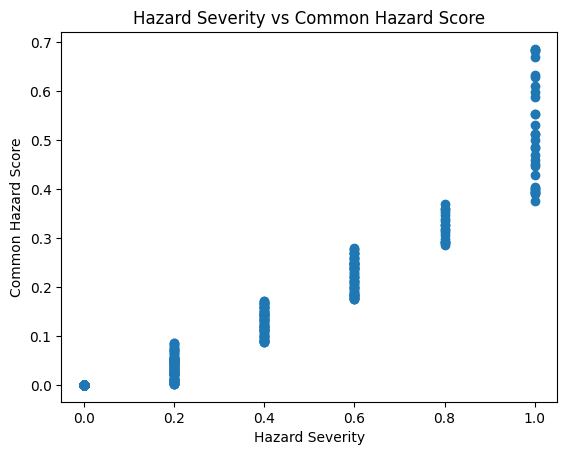

In [16]:
plt.scatter(
    df["hazard_severity"],
    df["hazard_score_common"]
)

plt.xlabel("Hazard Severity")
plt.ylabel("Common Hazard Score")
plt.title("Hazard Severity vs Common Hazard Score")
plt.show()

**Prepare the X and Y variables to train the model**

In [17]:
features = [
    "lat",
    "lon",
    "housing_class",
    "floor_area_m2",
    "cost_per_m2_kes",
    "tiv_kes"
]

targets = [
    "hazard_score_common",
    "hazard_score_occasional",
    "hazard_score_moderate",
    "hazard_score_severe",
    "hazard_score_extreme",
    "hazard_severity"
]

X = df[features]
y = df[targets]

In [18]:
X.head()

,lat,lon,housing_class,floor_area_m2,cost_per_m2_kes,tiv_kes
0,-1.314897,36.935883,semi_permanent,38,13600,5170000.0
1,-1.219963,36.789855,informal_iron_sheet,8,7800,625000.0
2,-1.257597,36.896201,semi_permanent,33,10000,3300000.0
3,-1.194103,36.847820,semi_permanent,58,13700,7945000.0
4,-1.263191,36.773582,semi_permanent,78,15900,12400000.0


In [19]:
y.head()

,hazard_score_common,hazard_score_occasional,hazard_score_moderate,hazard_score_severe,hazard_score_extreme,hazard_severity
0,0.023286,0.000000,0.000000,0.000000,0.000000,0.2
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.458406,0.407297,0.345205,0.247281,0.134603,1.0
3,0.113963,0.030351,0.000000,0.000000,0.000000,0.4
4,0.140621,0.059524,0.000000,0.000000,0.000000,0.4


In [20]:
print("Features:", X.shape)
print("Targets:", y.shape)

Features: (600, 6)
Targets: (600, 6)


**Split the data for training and testing the random forest model**

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Handle the House class using One-hot encoding**

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["housing_class"]

numerical_features = [
    "lat",
    "lon",
    "floor_area_m2",
    "cost_per_m2_kes",
    "tiv_kes"
]

The preprocessor to handle house class that is new to the model

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [24]:
print(df["housing_class"].unique())

['semi_permanent' 'informal_iron_sheet' 'permanent_masonry' 'concrete_rcc']


In [25]:
print(df["housing_class"].value_counts())

housing_class
semi_permanent         181
informal_iron_sheet    179
permanent_masonry      156
concrete_rcc            84
Name: count, dtype: int64


**apply the encoding**

In [26]:
X_encoded = preprocessor.fit_transform(X)

print(X_encoded.shape)

(600, 9)


**Random Forest model.**

In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [29]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [30]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['housing_class']),
                                                 ('numerical', 'passthrough',
                                                  ['lat', 'lon',
                                                   'floor_area_m2',
                                                   'cost_per_m2_kes',
                                                   'tiv_kes'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

**Testing the Model**

In [31]:
y_pred = pipeline.predict(X_test)

print(y_pred.shape)

(120, 6)


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for i, target in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"\n{target}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")


hazard_score_common
MAE:  0.0625
RMSE: 0.0997
R²:   0.5808

hazard_score_occasional
MAE:  0.0540
RMSE: 0.0979
R²:   0.5000

hazard_score_moderate
MAE:  0.0448
RMSE: 0.0950
R²:   0.3867

hazard_score_severe
MAE:  0.0319
RMSE: 0.0829
R²:   0.2689

hazard_score_extreme
MAE:  0.0222
RMSE: 0.0670
R²:   0.1845

hazard_severity
MAE:  0.1394
RMSE: 0.1967
R²:   0.6288


Comparing one real prediction with actuall value

In [33]:
comparison = pd.DataFrame({
    "actual": y_test.iloc[0].values,
    "predicted": y_pred[0]
}, index=targets)

print(comparison)

                           actual  predicted
hazard_score_common      0.243177   0.336339
hazard_score_occasional  0.171758   0.273711
hazard_score_moderate    0.084990   0.199303
hazard_score_severe      0.000000   0.107840
hazard_score_extreme     0.000000   0.042832
hazard_severity          0.600000   0.800000


In [34]:
print("Zero values:")
print((df == 0).sum())

Zero values:
loc_id                       0
lat                          0
lon                          0
housing_class                0
floor_area_m2                0
cost_per_m2_kes              0
tiv_kes                      0
synthetic                    0
source                       0
hazard_score_common        341
hazard_score_occasional    426
hazard_score_moderate      490
hazard_score_severe        549
hazard_score_extreme       568
hazard_severity            341
dtype: int64


In [35]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
loc_id                     0
lat                        0
lon                        0
housing_class              0
floor_area_m2              0
cost_per_m2_kes            0
tiv_kes                    0
synthetic                  0
source                     0
hazard_score_common        0
hazard_score_occasional    0
hazard_score_moderate      0
hazard_score_severe        0
hazard_score_extreme       0
hazard_severity            0
dtype: int64


Feature importance


In [36]:
import pandas as pd

# Get the encoded feature names
encoded_features = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get importance from the Random Forest
importances = pipeline.named_steps["model"].feature_importances_

# Put them together
feature_importance = pd.DataFrame({
    "feature": encoded_features,
    "importance": importances
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                                          feature  importance
5                                  numerical__lon    0.471505
4                                  numerical__lat    0.297845
7                      numerical__cost_per_m2_kes    0.078241
8                              numerical__tiv_kes    0.075848
6                        numerical__floor_area_m2    0.062162
2    categorical__housing_class_permanent_masonry    0.005872
3       categorical__housing_class_semi_permanent    0.004597
1  categorical__housing_class_informal_iron_sheet    0.001993
0         categorical__housing_class_concrete_rcc    0.001938


In [37]:
comparison_df = pd.DataFrame()

for i, target in enumerate(targets):
    comparison_df[f"{target}_actual"] = y_test.iloc[:, i].values
    comparison_df[f"{target}_predicted"] = y_pred[:, i]

print(comparison_df.head())

   hazard_score_common_actual  hazard_score_common_predicted  \
0                    0.243177                       0.336339   
1                    0.000000                       0.047621   
2                    0.000000                       0.052435   
3                    0.100644                       0.149817   
4                    0.158080                       0.319443   

   hazard_score_occasional_actual  hazard_score_occasional_predicted  \
0                        0.171758                           0.273711   
1                        0.000000                           0.029395   
2                        0.000000                           0.034160   
3                        0.015775                           0.088568   
4                        0.078630                           0.262945   

   hazard_score_moderate_actual  hazard_score_moderate_predicted  \
0                       0.08499                         0.199303   
1                       0.00000               

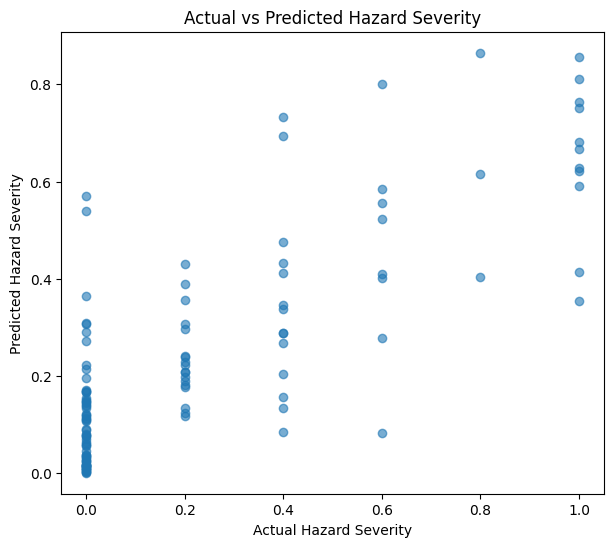

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test["hazard_severity"],
    y_pred[:, 5],
    alpha=0.6
)

plt.xlabel("Actual Hazard Severity")
plt.ylabel("Predicted Hazard Severity")
plt.title("Actual vs Predicted Hazard Severity")

plt.show()

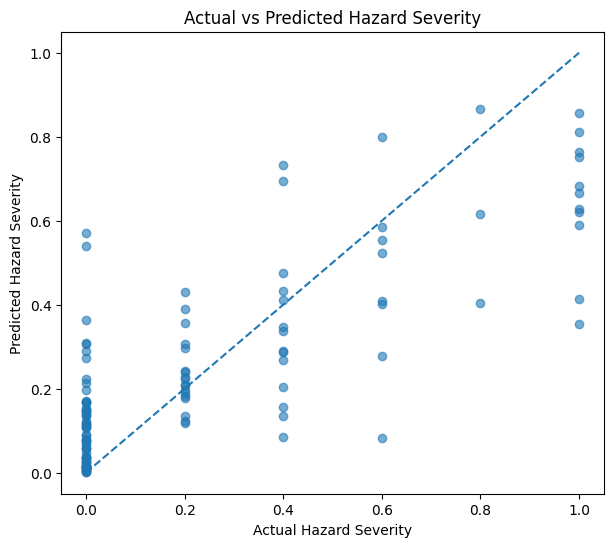

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test["hazard_severity"],
    y_pred[:, 5],
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual Hazard Severity")
plt.ylabel("Predicted Hazard Severity")
plt.title("Actual vs Predicted Hazard Severity")

plt.show()

In [40]:
import joblib

joblib.dump(
    pipeline,
    "hazard_random_forest.joblib"
)

['hazard_random_forest.joblib']

In [41]:
import os

print(os.path.exists("hazard_random_forest.joblib"))

True
